# Dataset Analysis for RDR2 Captures

This notebook analyzes the capture data from `all_captures.json` and uses metadata from `stats_summary_all_classes_final.json` to understand the distribution of classes, weather, and zones.

We will also create a balanced subset of capture IDs.

In [1]:
print("Hello")

Hello


In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import random

In [3]:
# Load the stats summary
with open('stats_summary_all_classes_final.json', 'r') as f:
    stats = json.load(f)

print("Stats loaded successfully.")

Stats loaded successfully.


In [4]:
# Load all captures (this may take time due to file size)
with open('all_captures.json', 'r') as f:
    captures = json.load(f)

print(f"Loaded {len(captures)} captures.")

Loaded 27494 captures.


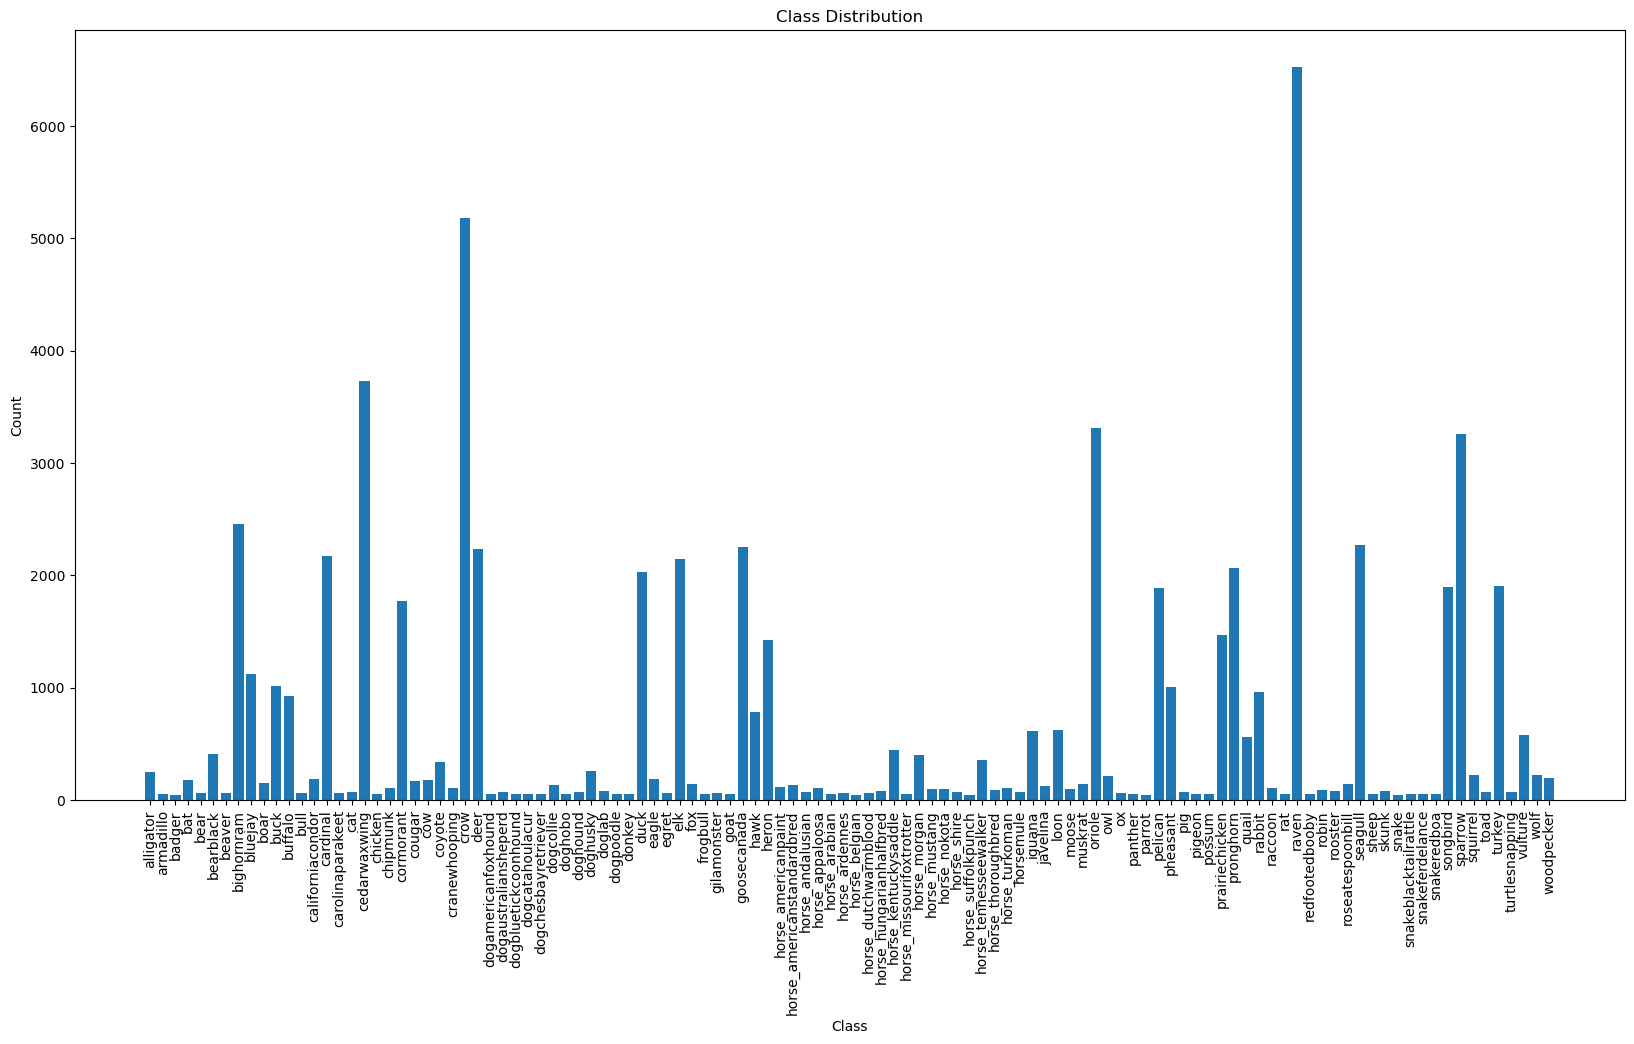

Top 10 classes:
raven: 6526
crow: 5183
cedarwaxwing: 3732
oriole: 3308
sparrow: 3256
bighornram: 2460
seagull: 2273
goosecanada: 2255
deer: 2232
cardinal: 2176


In [5]:
# Analyze class distribution
class_counts = stats['class_counts']
classes = list(class_counts.keys())
counts = list(class_counts.values())

plt.figure(figsize=(20, 10))
plt.bar(classes, counts)
plt.xticks(rotation=90)
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

# Print top 10 classes
sorted_classes = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
print("Top 10 classes:")
for cls, cnt in sorted_classes[:10]:
    print(f"{cls}: {cnt}")

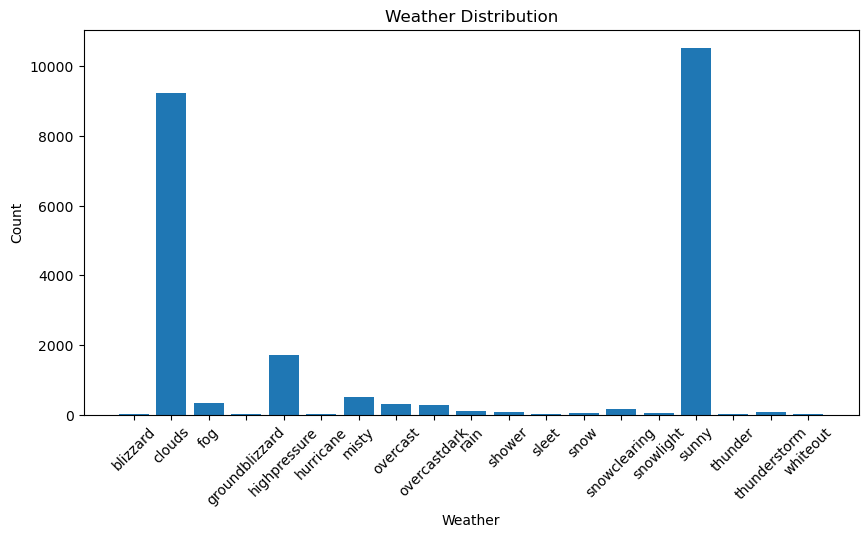

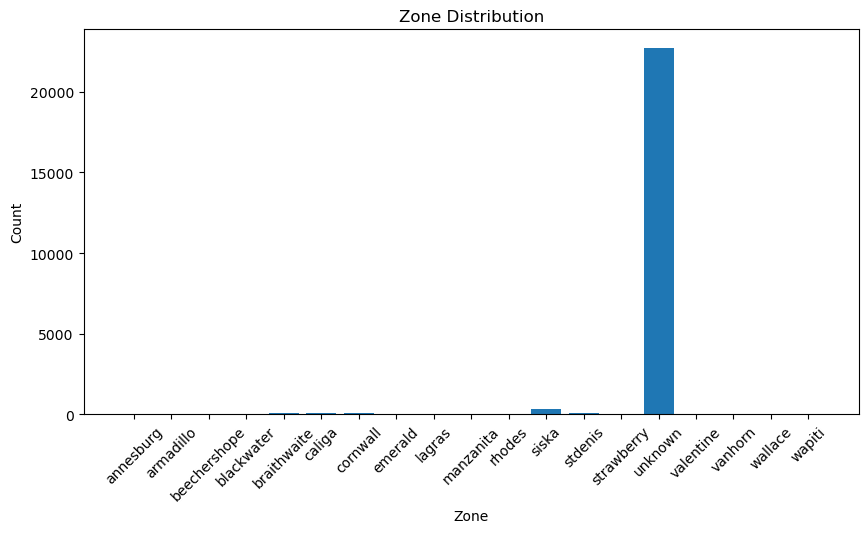

In [6]:
# Analyze weather distribution
weather_counts = stats['weather_counts']
weathers = list(weather_counts.keys())
w_counts = list(weather_counts.values())

plt.figure(figsize=(10, 5))
plt.bar(weathers, w_counts)
plt.xticks(rotation=45)
plt.title('Weather Distribution')
plt.xlabel('Weather')
plt.ylabel('Count')
plt.show()

# Analyze zone distribution
zone_counts = stats['zone_counts']
zones = list(zone_counts.keys())
z_counts = list(zone_counts.values())

plt.figure(figsize=(10, 5))
plt.bar(zones, z_counts)
plt.xticks(rotation=45)
plt.title('Zone Distribution')
plt.xlabel('Zone')
plt.ylabel('Count')
plt.show()

In [7]:
# Import the subset creation function
import importlib
import subset_creator
importlib.reload(subset_creator)
from subset_creator import create_balanced_subset

# Create a balanced subset with x images per class
x = 5
subset_ids = create_balanced_subset(captures, x)

print(f"Created subset with {len(subset_ids)} capture IDs.")
print("First 10 IDs:", subset_ids[:10])

Created subset with 553 capture IDs.
First 10 IDs: ['1034415', '1036273', '1000774', '1034409', '1002499', '1036190', '1000094', '1035706', '1000297', '1035916']


In [8]:
from subset_creation import create_subset

# Define source and destination roots for subset export
src_root = r"F:/RDR2_dataset_processed"
dst_root = r"G:/Subset"

# Create the dataset subset using the balanced IDs
create_subset(src_root, dst_root, subset_ids)
print(f"Subset created with {len(subset_ids)} IDs at {dst_root}")

100%|██████████| 553/553 [21:20<00:00,  2.32s/it] 


Subset creation complete.
Subset created with 553 IDs at G:/Subset


In [ ]:
# Get class distribution in the subset
subset_class_counts = defaultdict(int)
for cap_id in subset_ids:
    cap = captures[cap_id]
    for entity in cap['Entities']:
        cls = entity['FineClassName']
        subset_class_counts[cls] += 1

print("Class distribution in the subset:")
for cls, cnt in sorted(subset_class_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"{cls}: {cnt}")

Class distribution in the subset:
donkey: 48
rooster: 45
horsemule: 45
goosecanada: 42
dogaustraliansheperd: 40
horse_turkoman: 40
moose: 36
pelican: 36
horse_arabian: 35
buffalo: 35
dogamericanfoxhound: 34
doghound: 32
dogpoodle: 32
pigeon: 30
redfootedbooby: 30
horse_andalusian: 30
goat: 28
horse_missourifoxtrotter: 26
dogchesbayretriever: 26
snakeredboa: 25
cedarwaxwing: 24
dogcollie: 24
duck: 24
horse_dutchwarmblood: 20
cat: 20
carolinaparakeet: 20
horse_thoroughbred: 20
quail: 20
horse_ardennes: 20
pig: 20
parrot: 19
crow: 19
heron: 18
oriole: 18
seagull: 18
deer: 16
cormorant: 15
songbird: 15
doglab: 14
dogbluetickcoonhound: 14
cow: 14
horse_americanstandardbred: 14
horse_mustang: 14
prairiechicken: 13
sparrow: 13
dogcatahoulacur: 13
raven: 13
bat: 13
javelina: 13
horse_morgan: 12
pheasant: 12
coyote: 12
sheep: 12
horse_hungarianhalfbred: 12
roseatespoonbill: 12
wolf: 11
egret: 11
doghusky: 10
horse_suffolkpunch: 10
horse_nokota: 10
turkey: 9
doghobo: 9
horse_belgian: 9
boar: 9
e

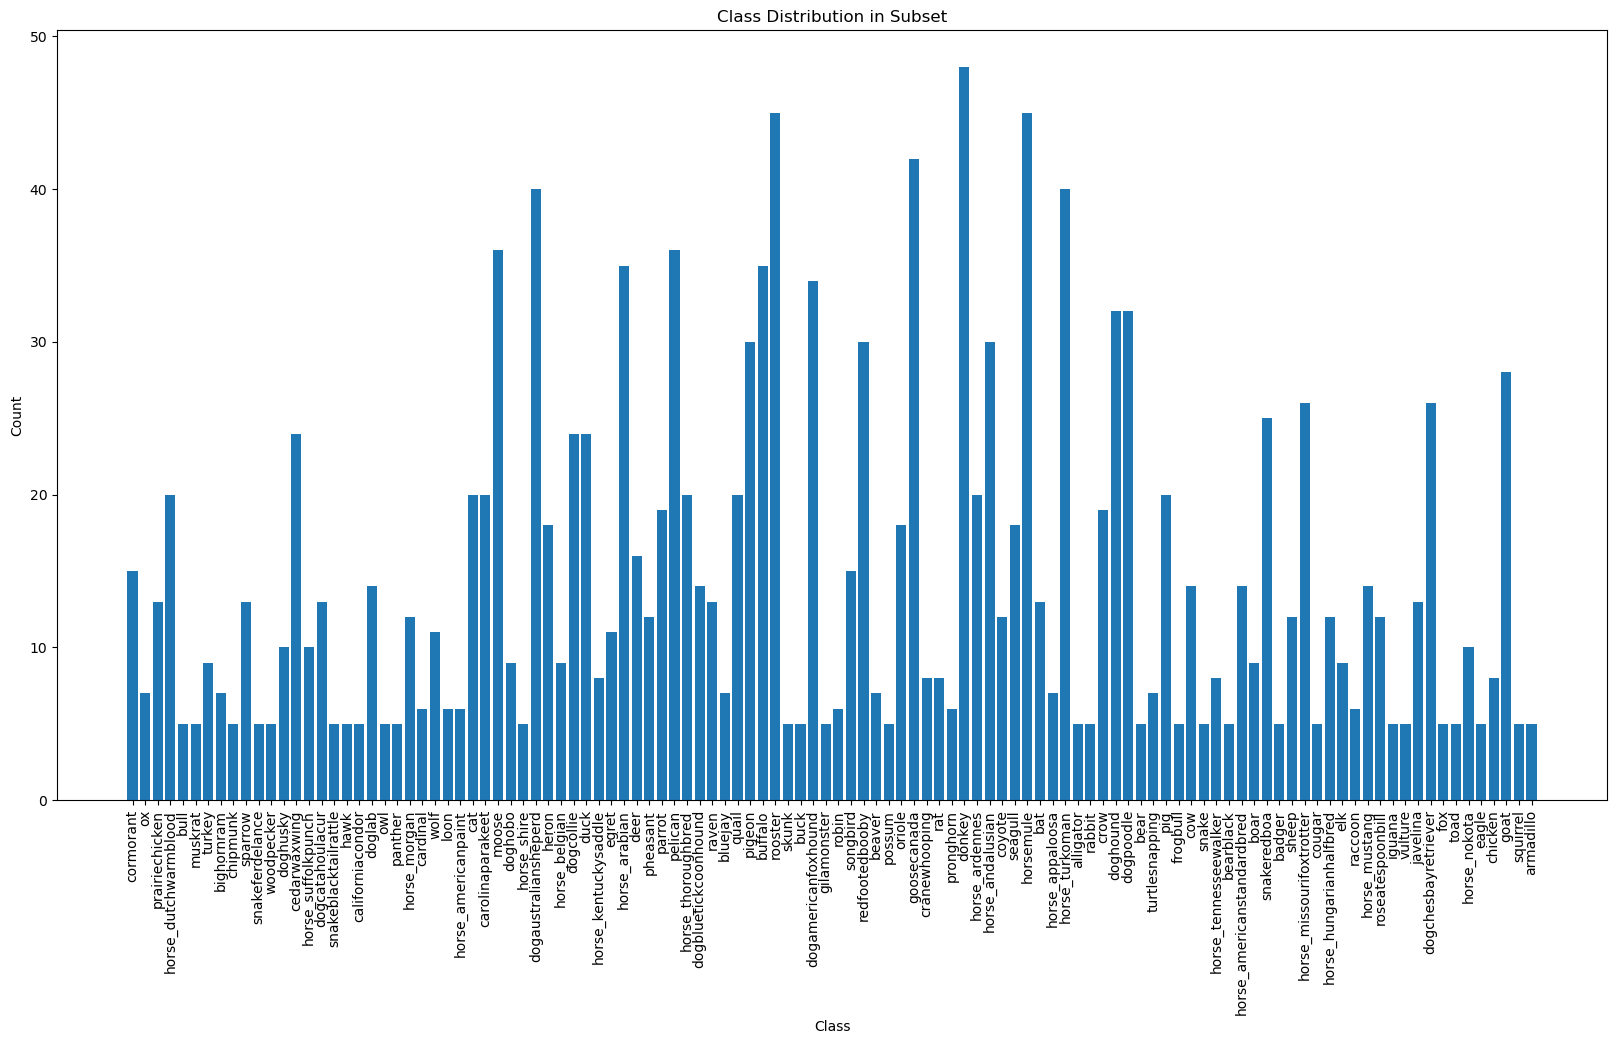

In [51]:
# Plot class distribution in the subset
subset_classes = list(subset_class_counts.keys())
subset_counts = list(subset_class_counts.values())
plt.figure(figsize=(20, 10))
plt.bar(subset_classes, subset_counts)
plt.xticks(rotation=90)
plt.title('Class Distribution in Subset')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [33]:
# Print lowest subset_class_counts values and keys
sorted_subset_classes = sorted(subset_class_counts.items(), key=lambda x: x[1])
print("Bottom 10 classes in the subset (lowest counts):")
for cls, cnt in sorted_subset_classes[:50]:
    print(f"{cls}: {cnt}")

Bottom 10 classes in the subset (lowest counts):
horse_suffolkpunch: 48
badger: 49
snake: 49
gilamonster: 50
bear: 50
horse_belgian: 50
parrot: 50
owl: 51
horse_arabian: 51
rat: 51
goat: 51
robin: 52
snakeblacktailrattle: 52
panther: 52
snakeferdelance: 52
armadillo: 52
pigeon: 52
snakeredboa: 53
cougar: 53
possum: 53
doghobo: 54
horse_missourifoxtrotter: 54
dogpoodle: 55
redfootedbooby: 56
dogamericanfoxhound: 56
frogbull: 56
dogbluetickcoonhound: 56
sheep: 56
chicken: 57
dogcatahoulacur: 59
bearblack: 59
donkey: 59
dogchesbayretriever: 59
woodpecker: 60
eagle: 60
horse_dutchwarmblood: 60
fox: 60
chipmunk: 61
carolinaparakeet: 61
bull: 61
skunk: 64
iguana: 67
horse_ardennes: 67
egret: 68
beaver: 68
ox: 68
dogaustraliansheperd: 69
muskrat: 69
horse_andalusian: 70
doghound: 71


In [34]:
# Get count of captures that contain at least one entity of a class per class for the subset
subset_class_capture_counts = defaultdict(set)
for cap_id in subset_ids:
    cap = captures[cap_id]
    for entity in cap['Entities']:
        cls = entity['FineClassName']
        subset_class_capture_counts[cls].add(cap_id)

print("Number of captures per class in the subset:")
for cls, cap_set in sorted(subset_class_capture_counts.items(), key=lambda x: len(x[1]), reverse=True):
    print(f"{cls}: {len(cap_set)}")

Number of captures per class in the subset:
raven: 190
deer: 148
elk: 142
pronghorn: 140
horse_tennesseewalker: 126
horse_kentuckysaddle: 117
horse_morgan: 110
songbird: 106
buck: 106
crow: 100
bighornram: 98
cardinal: 94
hawk: 91
turkey: 87
cedarwaxwing: 87
heron: 87
sparrow: 83
oriole: 83
vulture: 83
rabbit: 78
prairiechicken: 77
alligator: 76
bluejay: 72
duck: 72
californiacondor: 70
cormorant: 69
iguana: 67
coyote: 63
seagull: 63
loon: 62
pheasant: 62
woodpecker: 60
horse_americanstandardbred: 60
fox: 60
eagle: 59
muskrat: 59
bearblack: 59
goosecanada: 58
pelican: 56
squirrel: 56
buffalo: 56
doghusky: 56
horse_appaloosa: 55
horse_americanpaint: 55
skunk: 54
quail: 54
boar: 53
cougar: 53
horse_mustang: 53
roseatespoonbill: 53
raccoon: 52
horse_nokota: 52
cow: 52
robin: 51
bat: 51
owl: 51
javelina: 51
wolf: 51
cranewhooping: 51
horse_hungarianhalfbred: 50
chipmunk: 50
gilamonster: 50
horse_thoroughbred: 50
bear: 50
turtlesnapping: 50
badger: 48
possum: 43
horse_shire: 42
armadillo: 4

In [35]:
# Get count of captures that contain at least one entity of a class per class
class_capture_counts = defaultdict(set)
for cap_id, cap in captures.items():
    for entity in cap['Entities']:
        cls = entity['FineClassName']
        class_capture_counts[cls].add(cap_id)

print("Number of captures per class (full dataset):")
for cls, cap_set in sorted(class_capture_counts.items(), key=lambda x: len(x[1]), reverse=True):
    print(f"{cls}: {len(cap_set)}")

Number of captures per class (full dataset):
raven: 2674
cardinal: 1484
bighornram: 1471
deer: 1357
elk: 1218
crow: 1196
sparrow: 1177
cedarwaxwing: 1042
buck: 1014
oriole: 970
pronghorn: 963
bluejay: 812
hawk: 772
rabbit: 750
turkey: 737
cormorant: 710
iguana: 609
prairiechicken: 571
vulture: 561
seagull: 549
songbird: 454
loon: 438
bearblack: 414
goosecanada: 409
pelican: 402
duck: 400
pheasant: 356
horse_kentuckysaddle: 342
heron: 335
horse_morgan: 286
horse_tennesseewalker: 264
owl: 213
woodpecker: 191
eagle: 188
californiacondor: 188
cougar: 175
quail: 165
squirrel: 164
coyote: 158
alligator: 154
fox: 145
muskrat: 129
buffalo: 127
boar: 111
bat: 107
wolf: 102
chipmunk: 95
horse_americanstandardbred: 87
robin: 87
javelina: 76
raccoon: 76
skunk: 75
horse_appaloosa: 74
cranewhooping: 71
horse_americanpaint: 70
doghusky: 70
horse_mustang: 66
gilamonster: 64
bear: 62
roseatespoonbill: 60
horse_nokota: 58
cow: 54
turtlesnapping: 53
horse_hungarianhalfbred: 51
horse_thoroughbred: 50
badg